In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Environment ready!")


Environment ready!


In [2]:
dataset_path = r"C:\Users\Vishalini\PlantHealthAI\dataset"
print("Dataset path:", dataset_path)


Dataset path: C:\Users\Vishalini\PlantHealthAI\dataset


In [3]:
dataset_path = r"C:\Users\visha\Documents\plantHealth_AI\data\PlantVillage"
print(dataset_path)


C:\Users\visha\Documents\plantHealth_AI\data\PlantVillage


In [4]:
import os

classes = os.listdir(dataset_path)
print("Classes found:", classes)
print("Total classes:", len(classes))


Classes found: ['.ipynb_checkpoints', 'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Untitled.ipynb']
Total classes: 17


In [5]:
import os

first_class = classes[0]
class_path = os.path.join(dataset_path, first_class)

files = os.listdir(class_path)
print(files[:20])


['Untitled-checkpoint.ipynb']


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os


In [7]:
dataset_path = r"C:\Users\visha\Documents\plantHealth_AI\data\PlantVillage"
print("Dataset Path Set Successfully")


Dataset Path Set Successfully


In [8]:
classes = os.listdir(dataset_path)
print("Classes found:", classes)
print("Total classes:", len(classes))


Classes found: ['.ipynb_checkpoints', 'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Untitled.ipynb']
Total classes: 17


In [9]:
img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [10]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)


Found 16518 images belonging to 16 classes.


In [11]:
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Found 4122 images belonging to 16 classes.


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential()

# Input Layer
model.add(Input(shape=(224, 224, 3)))

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Third Convolution Layer
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(train_data.num_classes, activation='softmax'))


In [21]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [22]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)


Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 464s 894ms/step - accuracy: 0.5173 - loss: 1.5153 - val_accuracy: 0.7875 - val_loss: 0.7038
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 537s 1s/step - accuracy: 0.7117 - loss: 0.8679 - val_accuracy: 0.8188 - val_loss: 0.5470
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 451s 872ms/step - accuracy: 0.7796 - loss: 0.6676 - val_accuracy: 0.8399 - val_loss: 0.4539
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 470s 909ms/step - accuracy: 0.8169 - loss: 0.5441 - val_accuracy: 0.8697 - val_loss: 0.3851
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 470s 908ms/step - accuracy: 0.8413 - loss: 0.4580 - val_accuracy: 0.8675 - val_loss: 0.3999


In [23]:
model.save("plant_disease_model.h5")
print("Model saved successfully")


Model saved successfully


In [24]:
import numpy as np
from tensorflow.keras.preprocessing import image


In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create image data generator with validation split
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Training data
train_generator = train_datagen.flow_from_directory(
    "data/PlantVillage",
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# Validation data
validation_generator = train_datagen.flow_from_directory(
    "data/PlantVillage",
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 16518 images belonging to 16 classes.
Found 4122 images belonging to 16 classes.


In [26]:
import os

# Check current folder
print(os.getcwd())

# List all files in current folder
print(os.listdir())


C:\Users\visha\Documents\plantHealth_AI
['.ipynb_checkpoints', 'data', 'plantHealth_AI.ipynb', 'plant_disease_model.h5', 'plant_disease_model_final.h5', 'test.jpg']


In [27]:
import os

# Go to the main project folder where the model should be
os.chdir("C:\\Users\\visha\\Documents\\plantHealth_AI")

# Check current folder
print("Current folder:", os.getcwd())

# List all files in current folder
print(os.listdir())


Current folder: C:\Users\visha\Documents\plantHealth_AI
['.ipynb_checkpoints', 'data', 'plantHealth_AI.ipynb', 'plant_disease_model.h5', 'plant_disease_model_final.h5', 'test.jpg']


In [28]:
from tensorflow.keras.models import load_model

# Load the correct saved model
model = load_model("plant_disease_model.h5")
print("Model loaded successfully!")


Model loaded successfully!


In [29]:
train_generator = train_datagen.flow_from_directory(
    "data/PlantVillage",
    target_size=(224, 224),  # match old model
    batch_size=32,
    class_mode='categorical',
    subset='training'
)


Found 16518 images belonging to 16 classes.


In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build a new CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(16, activation='softmax')  # 16 classes
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("New CNN model is ready!")


New CNN model is ready!


C:\Users\visha\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [32]:
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    "data/PlantVillage",
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    "data/PlantVillage",
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 16518 images belonging to 16 classes.
Found 4122 images belonging to 16 classes.


In [33]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(16, activation='softmax')  # 16 classes
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

# Build CNN model (correct way)
model = Sequential([
    Input(shape=(128,128,3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(16, activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Model rebuilt successfully!")


Model rebuilt successfully!


In [35]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    verbose=1
)


Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 142s 271ms/step - accuracy: 0.4793 - loss: 1.6218 - val_accuracy: 0.7416 - val_loss: 0.7962
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 129s 250ms/step - accuracy: 0.6867 - loss: 0.9509 - val_accuracy: 0.7899 - val_loss: 0.6249
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 136s 262ms/step - accuracy: 0.7513 - loss: 0.7352 - val_accuracy: 0.8311 - val_loss: 0.4992
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 139s 269ms/step - accuracy: 0.7952 - loss: 0.6063 - val_accuracy: 0.8552 - val_loss: 0.4203
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 141s 273ms/step - accuracy: 0.8183 - loss: 0.5374 - val_accuracy: 0.8649 - val_loss: 0.3983


In [36]:
model.save("plant_disease_model_final.h5")
print("Model saved successfully!")


Model saved successfully!


In [37]:
loss, accuracy = model.evaluate(validation_generator)
print("Final Validation Accuracy:", accuracy)


129/129 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.8649 - loss: 0.3983
Final Validation Accuracy: 0.8648714423179626


In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Load model
model = load_model("plant_disease_model_final.h5")

# Check what size model expects
print("Model input shape:", model.input_shape)

# Load image with correct size (150x150)
img_path = "test.jpg"
img = image.load_img(img_path, target_size=(150,150))

# Show image
plt.imshow(img)
plt.axis('off')
plt.show()

# Prepare image
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Predict
prediction = model.predict(img_array)

print("Prediction:", prediction)


In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
import matplotlib.pyplot as plt

# Load model
model = load_model("plant_disease_model_final.h5")

# Load image (224x224 for VGG16)
img_path = "test.jpg"
img = image.load_img(img_path, target_size=(224,224))

plt.imshow(img)
plt.axis('off')
plt.show()

# Convert to array
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# IMPORTANT: Use VGG preprocess
img_array = preprocess_input(img_array)

# Predict
prediction = model.predict(img_array)

print("Prediction:", prediction)


In [ ]:
from tensorflow.keras.models import load_model

model = load_model("plant_disease_model_final.h5")
print(model.summary())


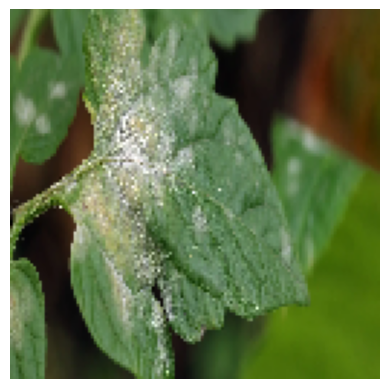

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
Prediction: [[2.0762404e-10 3.0975501e-05 2.6446378e-07 5.1800517e-04 2.1692052e-02
  1.6407483e-07 1.1320474e-04 5.2234340e-03 9.7206557e-01 1.7980579e-05
  1.6241560e-05 6.2952690e-06 4.2433862e-06 1.7330809e-04 6.0209254e-10
  1.3833991e-04]]


In [42]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Load model
model = load_model("plant_disease_model_final.h5")

# Load image with correct size (128x128)
img_path = "test.jpg"
img = image.load_img(img_path, target_size=(128,128))

# Show image
plt.imshow(img)
plt.axis('off')
plt.show()

# Convert to array
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Predict
prediction = model.predict(img_array)

print("Prediction:", prediction)


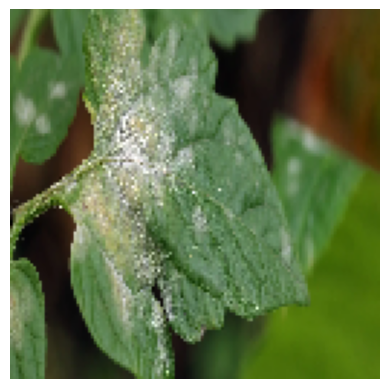

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Predicted Disease: Corn Common Rust


In [43]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Class names (change if your dataset order is different)
class_names = [
    'Apple Scab',
    'Apple Black Rot',
    'Apple Cedar Rust',
    'Apple Healthy',
    'Blueberry Healthy',
    'Cherry Powdery Mildew',
    'Cherry Healthy',
    'Corn Cercospora Leaf Spot',
    'Corn Common Rust',
    'Corn Healthy',
    'Grape Black Rot',
    'Grape Esca',
    'Grape Healthy',
    'Potato Early Blight',
    'Potato Healthy',
    'Tomato Late Blight'
]

# Load model
model = load_model("plant_disease_model_final.h5")

# Load image
img_path = "test.jpg"
img = image.load_img(img_path, target_size=(128,128))

# Show image
plt.imshow(img)
plt.axis('off')
plt.show()

# Prepare image
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Predict
prediction = model.predict(img_array)

# Get predicted class
predicted_class = class_names[np.argmax(prediction)]

print("Predicted Disease:", predicted_class)
